# Combined retrieval + image method


## 1. Setup


In [1]:
import gc
import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "doc_notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this experiment.")

image_embeddings = importlib.reload(importlib.import_module("doc_rag.10_image_embeddings"))
embedding_module = importlib.reload(importlib.import_module("doc_rag.5_embeddings"))
retrieval = importlib.reload(importlib.import_module("doc_rag.7_retrieval"))

IMAGE_MODEL = image_embeddings.DEFAULT_CONTEXT_MODEL  # E5 from notebook 8
TEXT_MODEL = "BAAI/bge-m3"  # locked earlier for text
TOP_K = 5
CANDIDATE_K = 30

CONTEXT_EMBED_ROOT = (
    PROJECT_ROOT / "data" / "rag" / "experiments"
    / "image_embedding_evaluation" / "embeddings"
)
STAGE_EMBED_ROOT = (
    PROJECT_ROOT / "data" / "rag" / "experiments"
    / "image_embedding_evaluation" / "stage_embeddings"
)
CASES_FILE = (
    PROJECT_ROOT / "data" / "rag" / "experiments"
    / "combined_text_image_retrieval" / "queries_with_ground_truth.json"
)
RESULTS_FILE = (
    PROJECT_ROOT / "data" / "rag" / "experiments"
    / "combined_text_image_retrieval" / "image_retrieval_method_results.json"
)

print("GPU:", torch.cuda.get_device_name(0))
print("Image model:", IMAGE_MODEL)
print("Image methods:", retrieval.IMAGE_RETRIEVAL_METHODS)
print("Default image method:", retrieval.DEFAULT_IMAGE_RETRIEVAL_METHOD)


GPU: NVIDIA GeForce MX570 A
Image model: intfloat/multilingual-e5-base
Image methods: ('context_dense', 'retrieve_rerank', 'retrieve_rerank_section', 'retrieve_rerank_fallback')
Default image method: retrieve_rerank_fallback


## 2. Load image records + evaluation cases

Loads `image_context.json` (no OCR). Uses queries that have `expected_image_ids`.


In [2]:
records = image_embeddings.load_image_records()
image_ids = {record["image_id"] for record in records}

with CASES_FILE.open(encoding="utf-8") as file:
    raw_cases = json.load(file)

evaluation_cases = []
for case in raw_cases:
    expected = list(case.get("expected_image_ids") or [])
    if not expected:
        continue
    missing = [image_id for image_id in expected if image_id not in image_ids]
    if missing:
        raise ValueError(f"Case {case['id']} missing images: {missing}")
    evaluation_cases.append(case)

stage_preview = pd.DataFrame(
    [image_embeddings.build_image_stage_texts(record) for record in records]
)
print("Images:", len(records))
print("Eval cases with image GT:", len(evaluation_cases))
print("Stage-1 sources:")
display(stage_preview["stage1_source"].value_counts().to_frame("count"))
print("Stage-2 sources:")
display(stage_preview["stage2_source"].value_counts().to_frame("count"))


Images: 480
Eval cases with image GT: 93
Stage-1 sources:


,count
stage1_source,
heading,480


Stage-2 sources:


,count
stage2_source,
nearby_vlm,480


## 3. Get or create embeddings (cached)

1. **Full context**: reuses notebook 8 cache when fingerprint matches  
2. **Stages**: new separate cache for retrieve-and-rerank  

First run of stages may take a few minutes; later runs should say `cache_hit=True`.


In [3]:
context_result = image_embeddings.get_or_create_image_embeddings(
    records,
    output_root=CONTEXT_EMBED_ROOT,
    context_model_name=IMAGE_MODEL,
    device="cuda",
    local_files_only=True,
    include_ocr=False,
)
context_embeddings = context_result["context_embeddings"]
print("Full-context cache_hit:", context_result["cache_hit"])
print("Full-context dir:", context_result["artifact_directory"])

stage_result = image_embeddings.get_or_create_image_stage_embeddings(
    records,
    output_root=STAGE_EMBED_ROOT,
    context_model_name=IMAGE_MODEL,
    device="cuda",
    local_files_only=True,
)
stage1_embeddings = stage_result["stage1_embeddings"]
stage2_embeddings = stage_result["stage2_embeddings"]
stage_meta = stage_result["metadata"]["images"]
stage2_sources = [item.get("stage2_source", "none") for item in stage_meta]
print("Stage cache_hit:", stage_result["cache_hit"])
print("Stage dir:", stage_result["artifact_directory"])

# Attach stage metadata onto records for inspection
records_with_stages = []
for record, meta in zip(records, stage_meta):
    merged = dict(record)
    merged["stage1_source"] = meta["stage1_source"]
    merged["stage2_source"] = meta["stage2_source"]
    merged["stage1_text"] = meta["stage1_text"]
    merged["stage2_text"] = meta["stage2_text"]
    records_with_stages.append(merged)


Full-context cache_hit: True
Full-context dir: C:\Users\User\Desktop\inmind\gatherly_rag\data\rag\experiments\image_embedding_evaluation\embeddings\intfloat__multilingual-e5-base
Stage cache_hit: True
Stage dir: C:\Users\User\Desktop\inmind\gatherly_rag\data\rag\experiments\image_embedding_evaluation\stage_embeddings\intfloat__multilingual-e5-base


## 4. Load E5 for image queries

Text stays on BGE in production; **image query embedding uses E5** (notebook 8 decision).


In [4]:
image_model = embedding_module.load_embedding_model(
    IMAGE_MODEL,
    device="cuda",
    local_files_only=True,
    model_kwargs={"torch_dtype": torch.float16},
)
print("Loaded image query model:", IMAGE_MODEL)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded image query model: intfloat/multilingual-e5-base


## 5. Compare image retrieval methods

Primary ranking: **coverage@5**, then **Recall@5**, then **MRR@5**.  
Coverage = fraction of expected images that appear in top-k.


In [5]:

# Priority for locking:
#   1) no wrong images  -> section_precision / id_precision
#   2) all gold images  -> coverage
#   3) classic hit rate -> recall / MRR

def coverage_at_k(retrieved_ids, expected_ids, k):
    """Fraction of labeled gold ids that appear in top-k (multi-label recall)."""
    expected = set(expected_ids)
    if not expected:
        return np.nan
    hit = sum(1 for image_id in retrieved_ids[:k] if image_id in expected)
    return hit / len(expected)


def id_precision_at_k(retrieved_ids, expected_ids, k):
    """Fraction of top-k retrieved ids that are in the gold id set."""
    top = list(retrieved_ids[:k])
    if not top:
        return np.nan
    expected = set(expected_ids)
    return sum(1 for image_id in top if image_id in expected) / len(top)


def section_precision_at_k(retrieved_sections, expected_sections, k):
    """Fraction of top-k whose section_title is in the expected section set."""
    top = list(retrieved_sections[:k])
    if not top:
        return np.nan
    expected = {str(s).strip() for s in expected_sections if str(s).strip()}
    if not expected:
        return np.nan
    return sum(1 for sec in top if str(sec or "").strip() in expected) / len(top)


def first_relevant_rank(retrieved_ids, expected_ids):
    expected = set(expected_ids)
    for rank, image_id in enumerate(retrieved_ids, start=1):
        if image_id in expected:
            return rank
    return None


def case_expected_sections(case, id_to_section):
    sections = {
        str(s).strip()
        for s in (case.get("expected_sections") or [])
        if str(s).strip()
    }
    if sections:
        return sections
    return {
        id_to_section[image_id]
        for image_id in case.get("expected_image_ids", [])
        if image_id in id_to_section and id_to_section[image_id]
    }


ID_TO_SECTION = {
    str(record["image_id"]): str(record.get("section_title") or "").strip()
    for record in records_with_stages
}

THRESHOLDS = [0.70, 0.75, 0.80, 0.82, 0.85, 0.88]
CANDIDATE_K = 15

# Primary sort keys for auto-lock (highest first).
# Wrong images off-screen first, then cover all gold images.
# Prefer confidence fallback over hard section-only; lift coverage/recall a bit.
PREFERRED_FAMILY = "fallback"  # "fallback" | "section" | "any"
PREFERRED_CONFIDENCE = 0.85
MIN_SECTION_PRECISION = 0.50
W_SECTION, W_ID, W_COVERAGE, W_RECALL = 0.25, 0.05, 0.35, 0.35

SELECTION_PRIORITY = [
    "lock_score",
    "section_precision_at_5",
    "coverage_at_5",
    "recall_at_5",
    "mrr_at_5",
]

IMAGE_METHODS = {
    "context_dense": {
        "method": "context_dense",
        "kwargs": {"context_embeddings": context_embeddings},
    },
    "retrieve_rerank_k15": {
        "method": "retrieve_rerank",
        "kwargs": {
            "stage1_embeddings": stage1_embeddings,
            "context_embeddings": context_embeddings,
            "candidate_k": CANDIDATE_K,
        },
    },
    "retrieve_rerank_section_k15": {
        "method": "retrieve_rerank_section",
        "kwargs": {
            "stage1_embeddings": stage1_embeddings,
            "context_embeddings": context_embeddings,
            "candidate_k": CANDIDATE_K,
        },
    },
}
for t in THRESHOLDS:
    IMAGE_METHODS[f"fallback_t{t:.2f}"] = {
        "method": "retrieve_rerank_fallback",
        "kwargs": {
            "stage1_embeddings": stage1_embeddings,
            "context_embeddings": context_embeddings,
            "candidate_k": CANDIDATE_K,
            "confidence_threshold": t,
        },
    }

method_metric_rows = []
case_result_rows = []

for label, spec in IMAGE_METHODS.items():
    print("METHOD:", label)
    ranks = []
    coverages = []
    id_precs = []
    section_precs = []
    n_retrieved = []
    n_fallback = 0
    for case in evaluation_cases:
        results = retrieval.retrieve_images(
            case["query"],
            method=spec["method"],
            model=image_model,
            model_name=IMAGE_MODEL,
            top_k=TOP_K,
            image_records=records_with_stages,
            **spec["kwargs"],
        )
        if len(results) and "fallback_used" in results.columns and bool(
            results.iloc[0]["fallback_used"]
        ):
            n_fallback += 1
        retrieved_ids = results["image_id"].tolist() if len(results) else []
        retrieved_sections = (
            results["section_title"].tolist()
            if len(results) and "section_title" in results.columns
            else [ID_TO_SECTION.get(image_id, "") for image_id in retrieved_ids]
        )
        expected = case["expected_image_ids"]
        expected_sections = case_expected_sections(case, ID_TO_SECTION)
        rank = first_relevant_rank(retrieved_ids, expected)
        cov = coverage_at_k(retrieved_ids, expected, TOP_K)
        id_prec = id_precision_at_k(retrieved_ids, expected, TOP_K)
        sec_prec = section_precision_at_k(
            retrieved_sections, expected_sections, TOP_K
        )
        ranks.append(rank)
        coverages.append(cov)
        id_precs.append(id_prec)
        section_precs.append(sec_prec)
        n_retrieved.append(len(retrieved_ids))
        case_result_rows.append({
            "method": label,
            "case_id": case["id"],
            "query": case["query"],
            "expected_image_ids": expected,
            "expected_sections": sorted(expected_sections),
            "first_relevant_rank": rank,
            "coverage_at_5": None if pd.isna(cov) else round(float(cov), 4),
            "id_precision_at_5": (
                None if pd.isna(id_prec) else round(float(id_prec), 4)
            ),
            "section_precision_at_5": (
                None if pd.isna(sec_prec) else round(float(sec_prec), 4)
            ),
            "n_retrieved": len(retrieved_ids),
            "retrieved_image_ids": retrieved_ids,
            "retrieved_sections": retrieved_sections,
        })
    if label.startswith("fallback_"):
        print(f"  dense fallback used on {n_fallback}/{len(evaluation_cases)} cases")
    reciprocal = [0.0 if r is None else 1.0 / r for r in ranks]
    method_metric_rows.append({
        "method": label,
        "cases": len(evaluation_cases),
        "section_precision_at_5": round(float(np.nanmean(section_precs)), 4),
        "id_precision_at_5": round(float(np.nanmean(id_precs)), 4),
        "coverage_at_5": round(float(np.nanmean(coverages)), 4),
        "recall_at_1": round(
            float(np.mean([r is not None and r <= 1 for r in ranks])), 4
        ),
        "recall_at_3": round(
            float(np.mean([r is not None and r <= 3 for r in ranks])), 4
        ),
        "recall_at_5": round(
            float(np.mean([r is not None and r <= 5 for r in ranks])), 4
        ),
        "mrr_at_5": round(float(np.mean(reciprocal)), 4),
        "mean_n_retrieved": round(float(np.mean(n_retrieved)), 4),
        "fallback_rate": (
            round(n_fallback / len(evaluation_cases), 4)
            if label.startswith("fallback_")
            else None
        ),
    })

method_metrics = pd.DataFrame(method_metric_rows).copy()
case_results = pd.DataFrame(case_result_rows)

method_metrics["lock_score"] = (
    W_SECTION * method_metrics["section_precision_at_5"].fillna(0)
    + W_ID * method_metrics["id_precision_at_5"].fillna(0)
    + W_COVERAGE * method_metrics["coverage_at_5"].fillna(0)
    + W_RECALL * method_metrics["recall_at_5"].fillna(0)
).round(4)

method_metrics["is_fallback"] = method_metrics["method"].str.startswith("fallback_").astype(int)
method_metrics["is_section_only"] = method_metrics["method"].str.startswith(
    "retrieve_rerank_section"
).astype(int)

def _threshold_from_label(label: str):
    if not str(label).startswith("fallback_t"):
        return None
    return float(str(label).replace("fallback_t", ""))

method_metrics["confidence_threshold"] = method_metrics["method"].map(_threshold_from_label)
method_metrics["confidence_distance"] = method_metrics["confidence_threshold"].apply(
    lambda t: abs(t - PREFERRED_CONFIDENCE) if t is not None else 999.0
)

eligible = method_metrics[
    method_metrics["section_precision_at_5"].fillna(0) >= MIN_SECTION_PRECISION
].copy()
if eligible.empty:
    print("WARNING: no method met MIN_SECTION_PRECISION; using full table.")
    eligible = method_metrics.copy()

if PREFERRED_FAMILY == "fallback":
    preferred = eligible[eligible["is_fallback"] == 1]
    if len(preferred):
        eligible = preferred
elif PREFERRED_FAMILY == "section":
    preferred = eligible[eligible["is_section_only"] == 1]
    if len(preferred):
        eligible = preferred

eligible = eligible.sort_values(
    ["lock_score", "confidence_distance", "coverage_at_5", "recall_at_5", "mrr_at_5"],
    ascending=[False, True, False, False, False],
).reset_index(drop=True)

method_metrics = method_metrics.sort_values(
    ["lock_score", "section_precision_at_5", "coverage_at_5", "recall_at_5"],
    ascending=False,
).reset_index(drop=True)
AUTO_LOCK_LABEL = str(eligible.iloc[0]["method"])

print("PREFERRED_FAMILY:", PREFERRED_FAMILY)
print("PREFERRED_CONFIDENCE:", PREFERRED_CONFIDENCE)
print("MIN_SECTION_PRECISION:", MIN_SECTION_PRECISION)
print("Auto-lock candidate:", AUTO_LOCK_LABEL)
display(Markdown(
    f"**Auto-lock:** section_precision ≥ {MIN_SECTION_PRECISION}, "
    f"prefer **{PREFERRED_FAMILY}**, threshold near **{PREFERRED_CONFIDENCE}**."
))
display(Markdown("### Eligible ranking (used for auto-lock)"))
display(eligible)
display(Markdown("### Full method table (by lock_score)"))
display(method_metrics)

METHOD: context_dense
METHOD: retrieve_rerank_k15
METHOD: retrieve_rerank_section_k15
METHOD: fallback_t0.70
  dense fallback used on 0/93 cases
METHOD: fallback_t0.75
  dense fallback used on 0/93 cases
METHOD: fallback_t0.80
  dense fallback used on 0/93 cases
METHOD: fallback_t0.82
  dense fallback used on 3/93 cases
METHOD: fallback_t0.85
  dense fallback used on 38/93 cases
METHOD: fallback_t0.88
  dense fallback used on 87/93 cases
PREFERRED_FAMILY: fallback
PREFERRED_CONFIDENCE: 0.85
MIN_SECTION_PRECISION: 0.5
Auto-lock candidate: fallback_t0.85


**Auto-lock:** section_precision ≥ 0.5, prefer **fallback**, threshold near **0.85**.

### Eligible ranking (used for auto-lock)

,method,cases,section_precision_at_5,id_precision_at_5,coverage_at_5,recall_at_1,recall_at_3,recall_at_5,mrr_at_5,mean_n_retrieved,fallback_rate,lock_score,is_fallback,is_section_only,confidence_threshold,confidence_distance
0,fallback_t0.85,93,0.5462,0.5366,0.6961,0.6344,0.7527,0.7742,0.6907,3.3011,0.4086,0.6780,1,0,0.85,0.00
1,fallback_t0.82,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.3118,0.0323,0.6748,1,0,0.82,0.03
2,fallback_t0.80,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.1828,0.0000,0.6748,1,0,0.80,0.05
3,fallback_t0.75,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.1828,0.0000,0.6748,1,0,0.75,0.10
4,fallback_t0.70,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.1828,0.0000,0.6748,1,0,0.70,0.15


### Full method table (by lock_score)

,method,cases,section_precision_at_5,id_precision_at_5,coverage_at_5,recall_at_1,recall_at_3,recall_at_5,mrr_at_5,mean_n_retrieved,fallback_rate,lock_score,is_fallback,is_section_only,confidence_threshold,confidence_distance
0,fallback_t0.85,93,0.5462,0.5366,0.6961,0.6344,0.7527,0.7742,0.6907,3.3011,0.4086,0.6780,1,0,0.85,0.00
1,retrieve_rerank_section_k15,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.1828,NaN,0.6748,0,1,NaN,NaN
2,fallback_t0.70,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.1828,0.0000,0.6748,1,0,0.70,0.15
3,fallback_t0.75,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.1828,0.0000,0.6748,1,0,0.75,0.10
4,fallback_t0.80,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.1828,0.0000,0.6748,1,0,0.80,0.05
5,fallback_t0.82,93,0.6774,0.6636,0.6610,0.6667,0.6882,0.6882,0.6756,2.3118,0.0323,0.6748,1,0,0.82,0.03
6,retrieve_rerank_k15,93,0.2882,0.2882,0.7583,0.6667,0.8495,0.8710,0.7522,5.0000,NaN,0.6567,0,0,NaN,NaN
7,context_dense,93,0.2817,0.2796,0.7490,0.5806,0.8172,0.8817,0.6975,5.0000,NaN,0.6552,0,0,NaN,NaN
8,fallback_t0.88,93,0.2946,0.2925,0.7336,0.5806,0.8065,0.8495,0.6896,4.8172,0.9355,0.6424,1,0,0.88,0.03


## 6. Inspect special case B2 + disagreements


,method,first_relevant_rank,coverage_at_5,retrieved_image_ids
1,context_dense,1.0,0.3333,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-5..."
94,retrieve_rerank_k15,1.0,0.3333,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-5..."
187,retrieve_rerank_section_k15,1.0,1.0000,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-2..."
280,fallback_t0.70,1.0,1.0000,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-2..."
373,fallback_t0.75,1.0,1.0000,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-2..."
466,fallback_t0.80,1.0,1.0000,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-2..."
559,fallback_t0.82,1.0,1.0000,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-2..."
652,fallback_t0.85,1.0,1.0000,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-2..."
745,fallback_t0.88,1.0,0.3333,"[Boho_Wedding-2ddfce16cb5b4334, Boho_Wedding-5..."


### Case `B2`
**Query:** How can I help guests find their places at a boho wedding?

### Expected images

o`Boho_Wedding-2ddfce16cb5b4334`  
section: 7. Have Fun With Your Boho Wedding Seating / Show Guests to Their Seats in Bohemian Style  
stage1=`heading` stage2=`nearby_vlm`

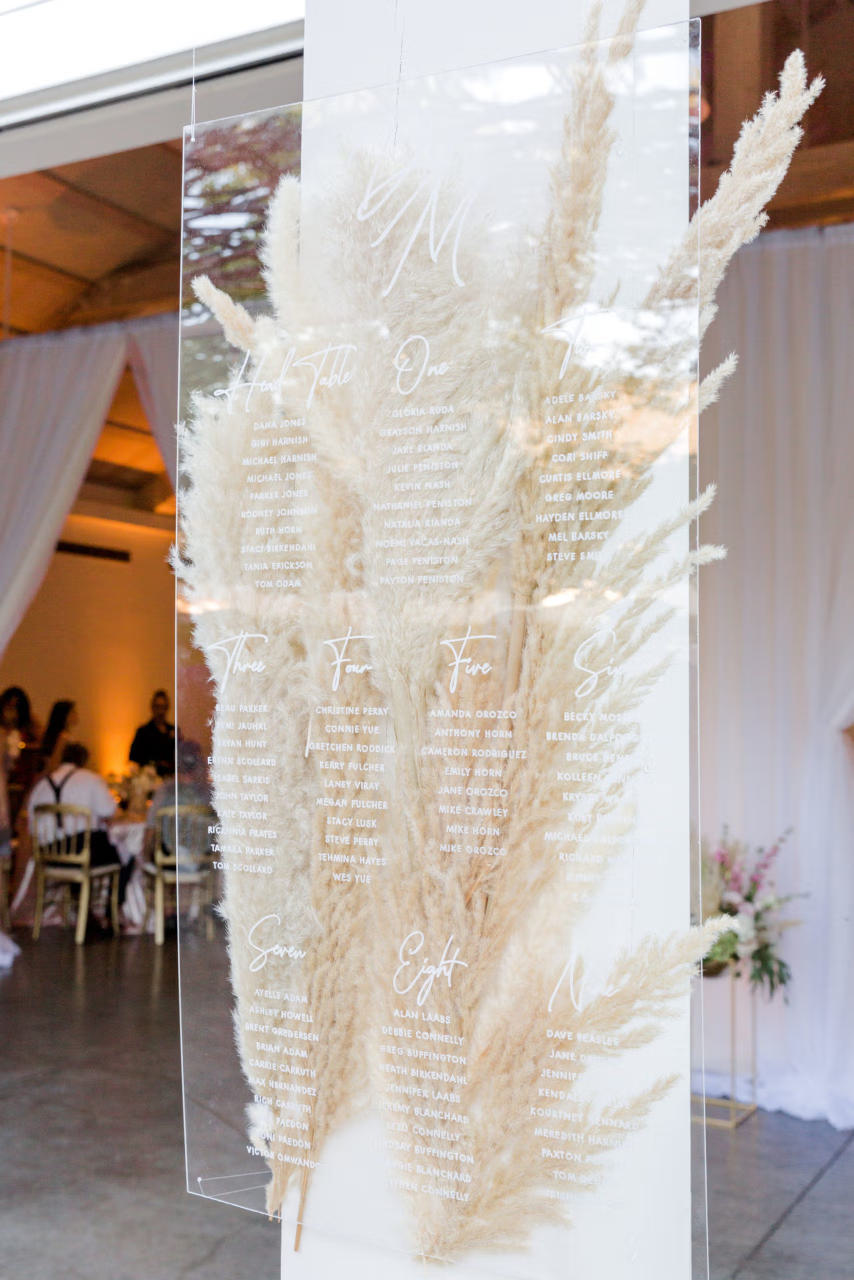

o`Boho_Wedding-f238278c29921a1a`  
section: 7. Have Fun With Your Boho Wedding Seating / Number Your Tables With a Botanical Touch  
stage1=`heading` stage2=`nearby_vlm`

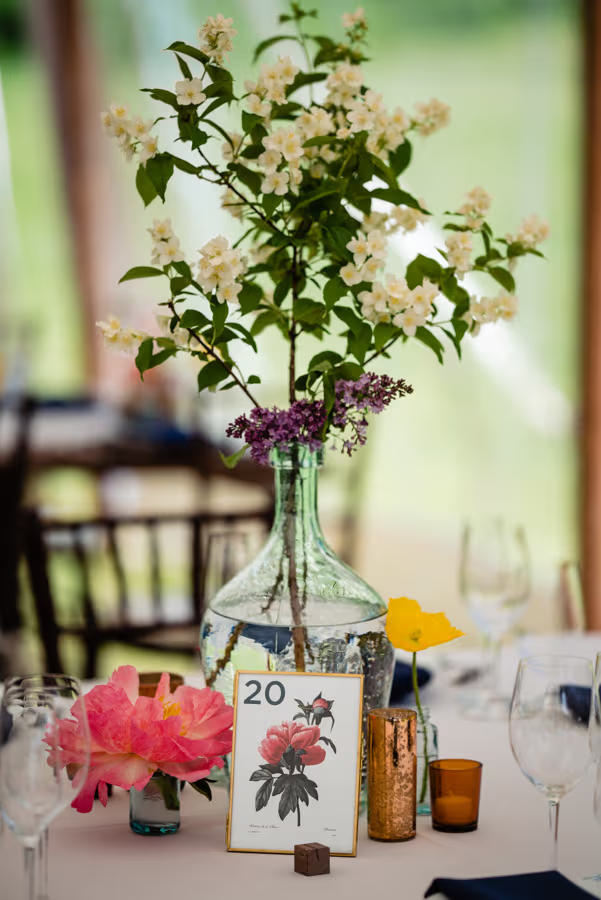

o`Boho_Wedding-768477346810f6e5`  
section: 7. Have Fun With Your Boho Wedding Seating / Consider Beautifully-Boho Thrones for You &  
stage1=`heading` stage2=`nearby_vlm`

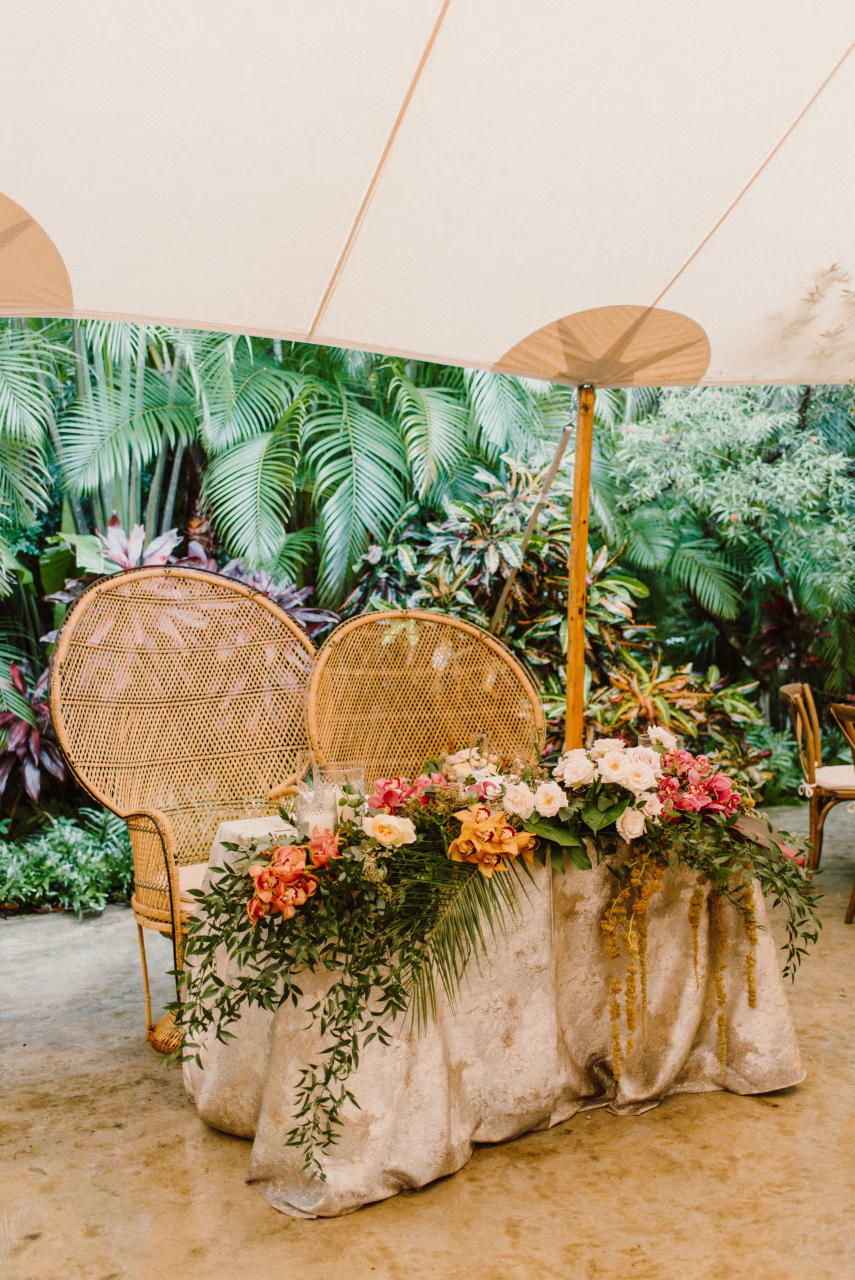

### Retrieved by `context_dense`  
coverage@5=0.3333 - first_relevant_rank=1.0

**#1** o

`Boho_Wedding-2ddfce16cb5b4334`  
section: 7. Have Fun With Your Boho Wedding Seating / Show Guests to Their Seats in Bohemian Style  
stage1=`heading` stage2=`nearby_vlm`

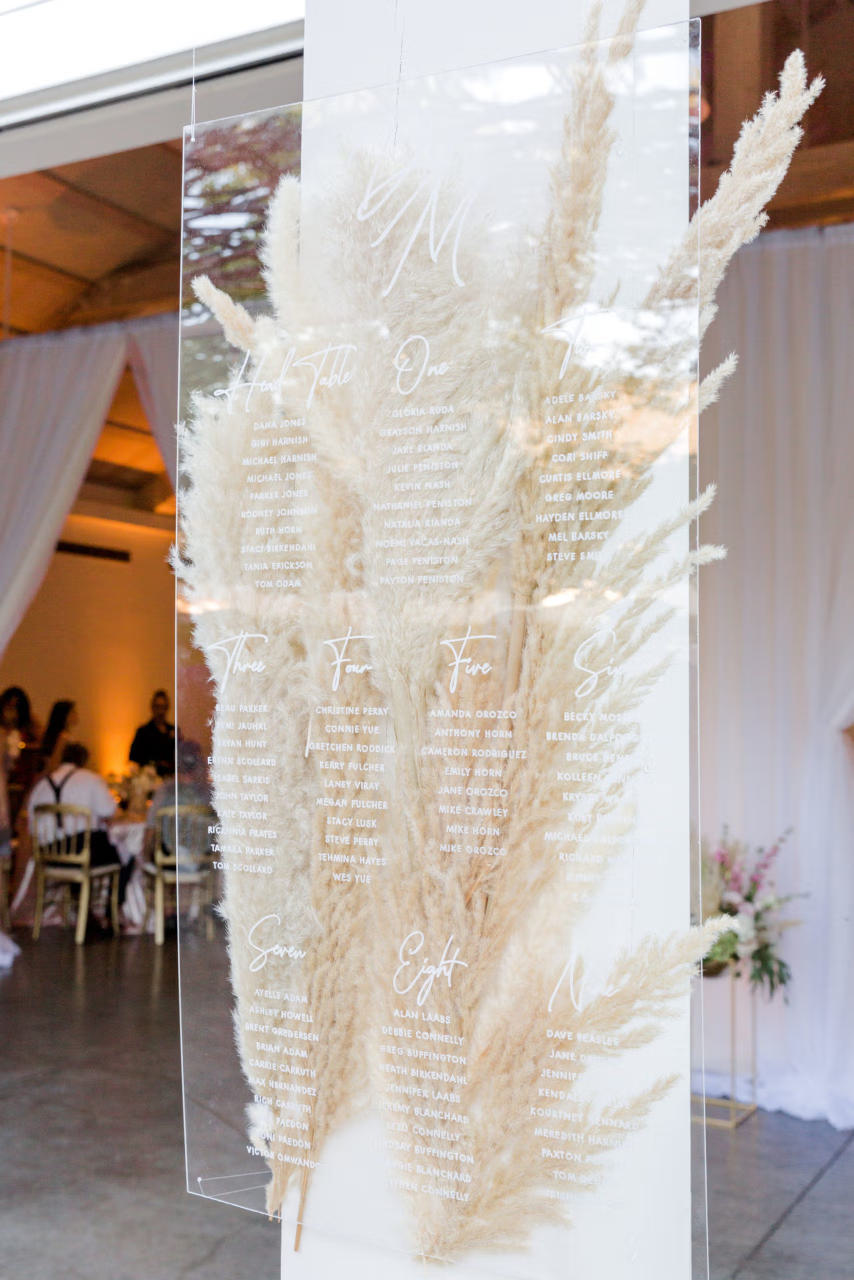

**#2** ·

`Boho_Wedding-5213f4455f181010`  
section: 5. Consider Your Boho Wedding Guests / Make Your Guests Comfortable  
stage1=`heading` stage2=`nearby_vlm`

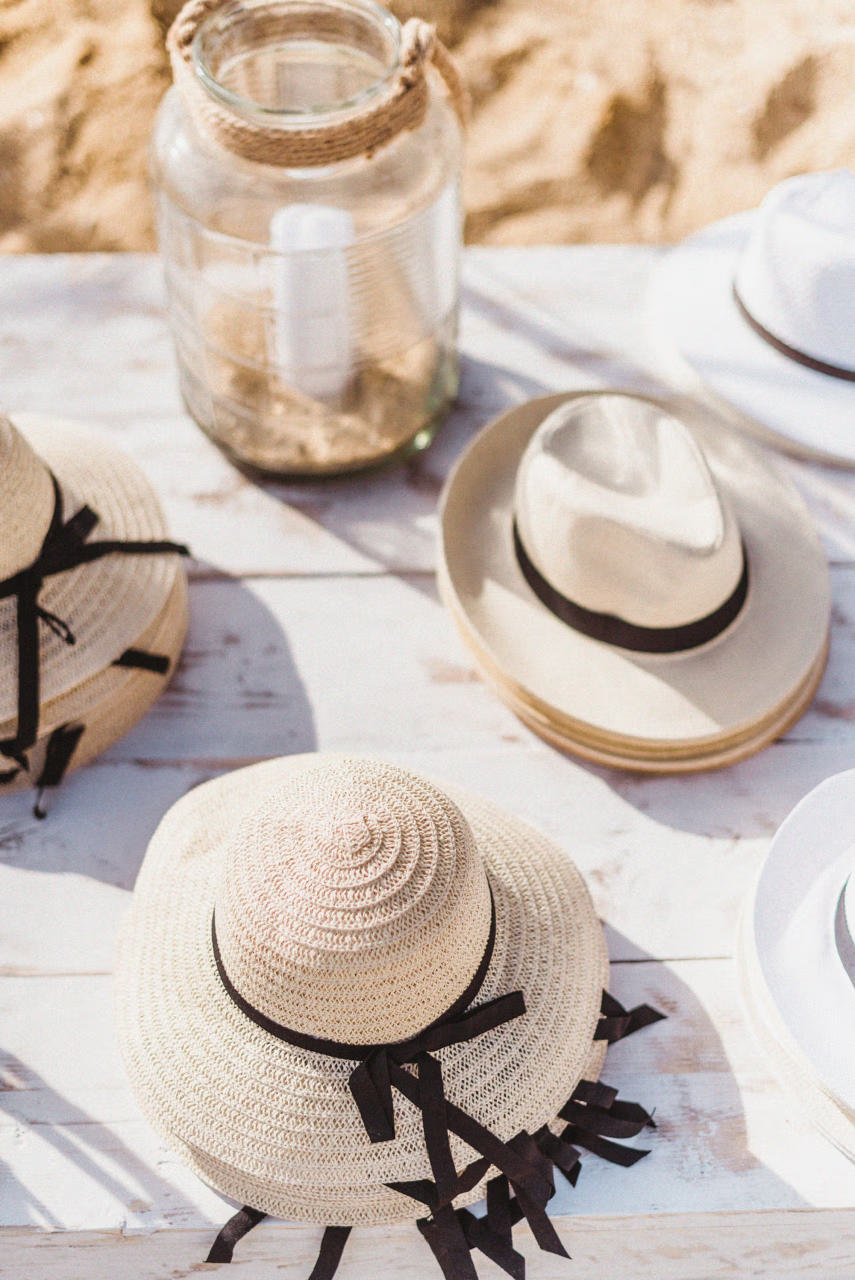

**#3** ·

`Boho_Wedding-3b2ae1b817892616`  
section: 2. Select Your Boho Wedding Venue / Enclose Big Spaces for a More Intimate Feel  
stage1=`heading` stage2=`nearby_vlm`

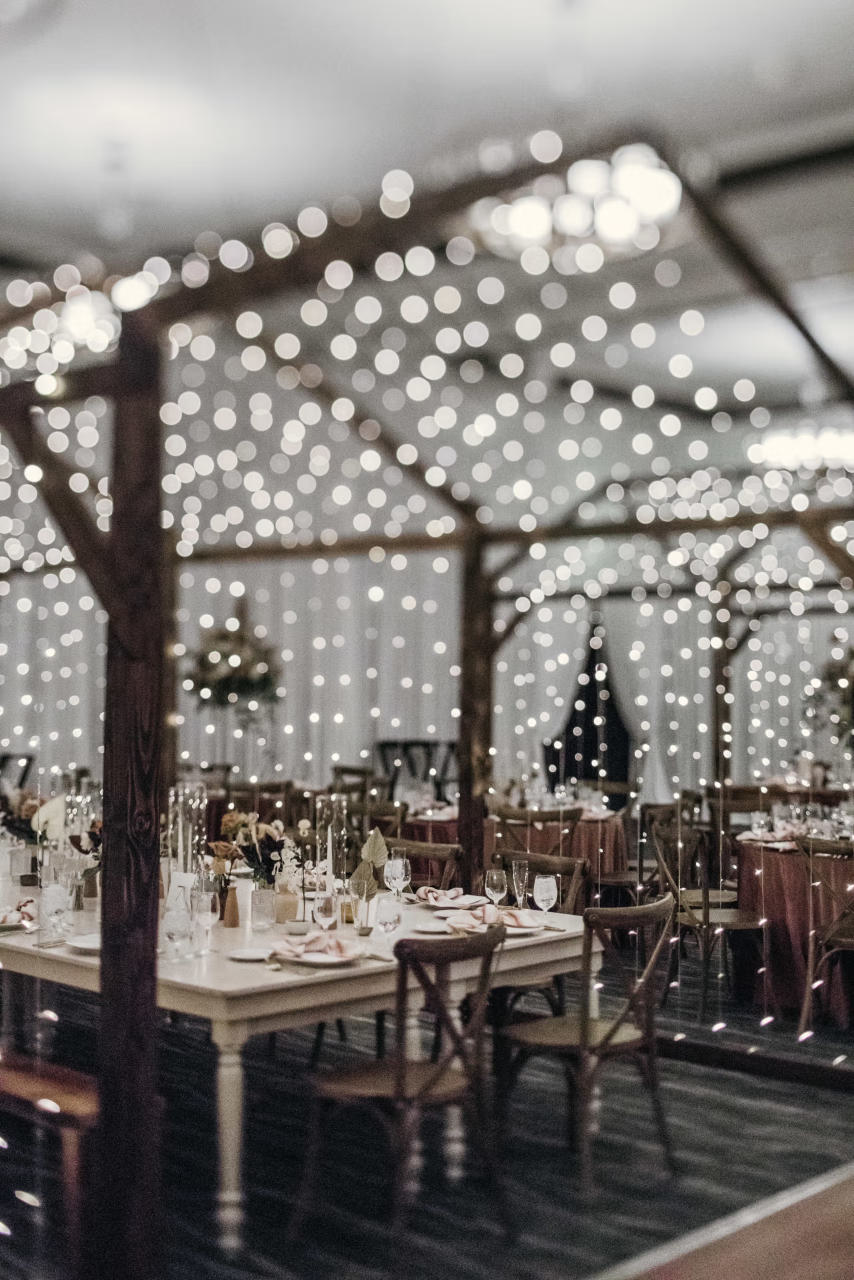

**#4** ·

`Boho_Wedding-621d60e70a5992e5`  
section: 13. Create Luxe Lounge Areas For Your Boho Wedding Guests / Create a Backdrop With Vintage Fabric  
stage1=`heading` stage2=`nearby_vlm`

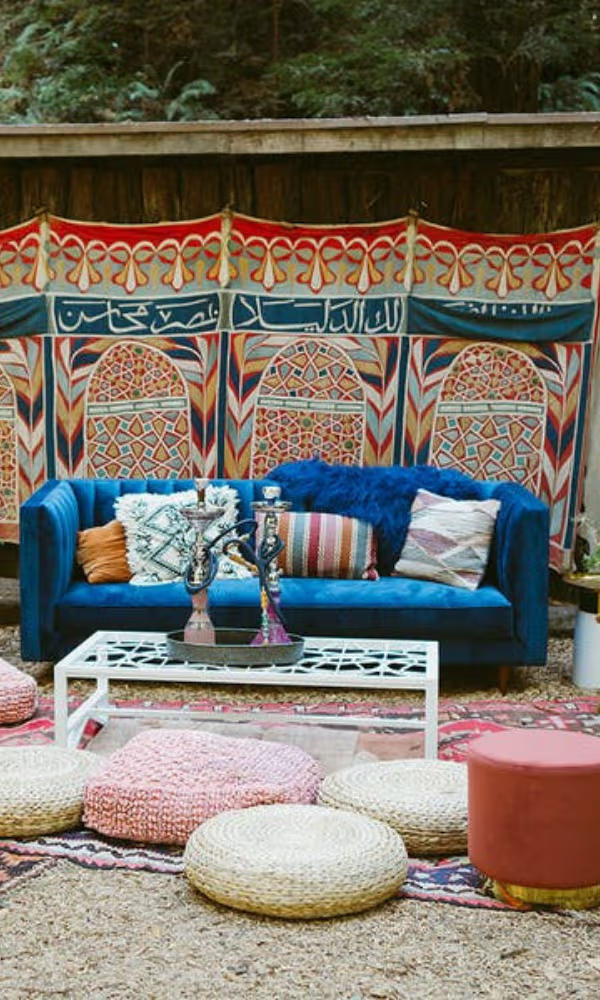

**#5** ·

`Boho_Wedding-200536b6836d3dda`  
section: 7. Have Fun With Your Boho Wedding Seating / Frame Your Sweetheart Table with Boho Décor  
stage1=`heading` stage2=`nearby_vlm`

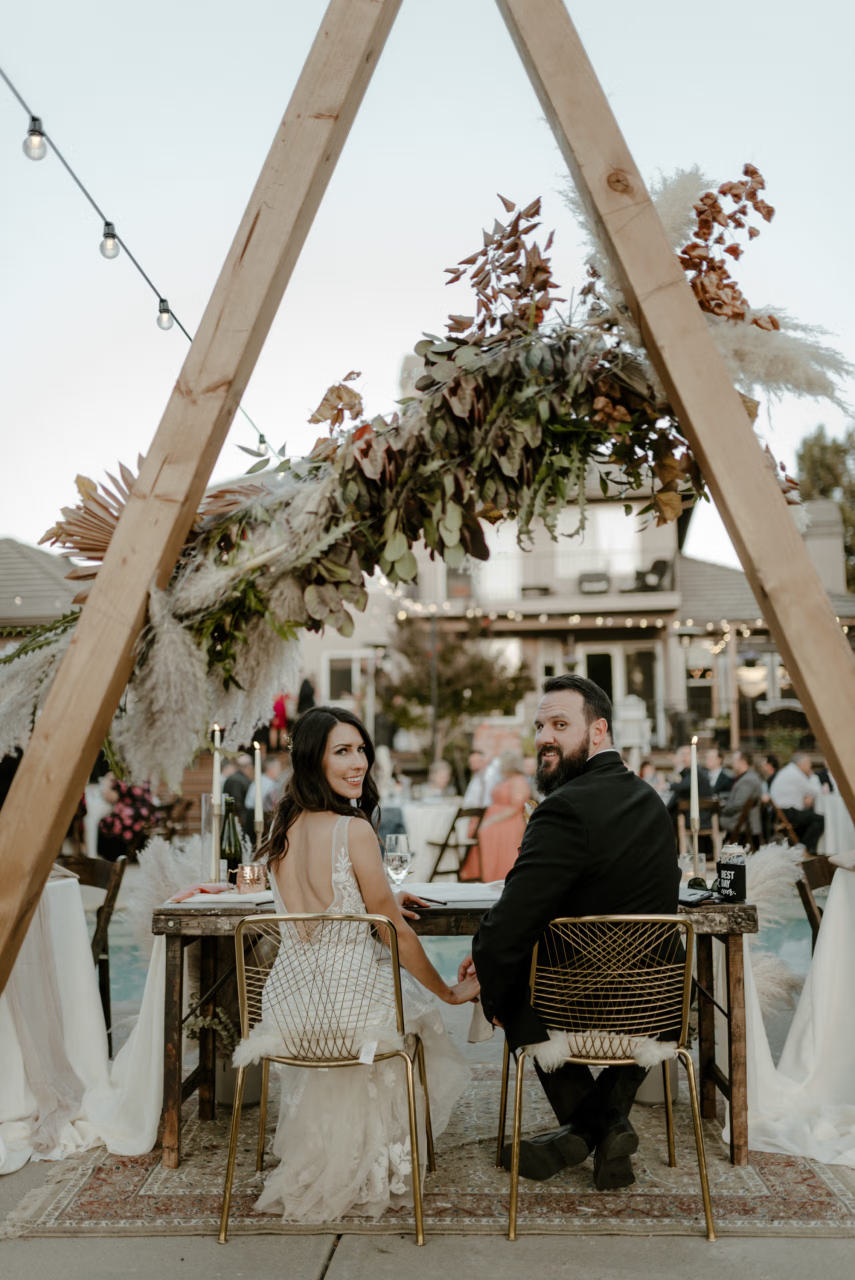

### Retrieved by `retrieve_rerank_k15`  
coverage@5=0.3333 - first_relevant_rank=1.0

**#1** o

`Boho_Wedding-2ddfce16cb5b4334`  
section: 7. Have Fun With Your Boho Wedding Seating / Show Guests to Their Seats in Bohemian Style  
stage1=`heading` stage2=`nearby_vlm`

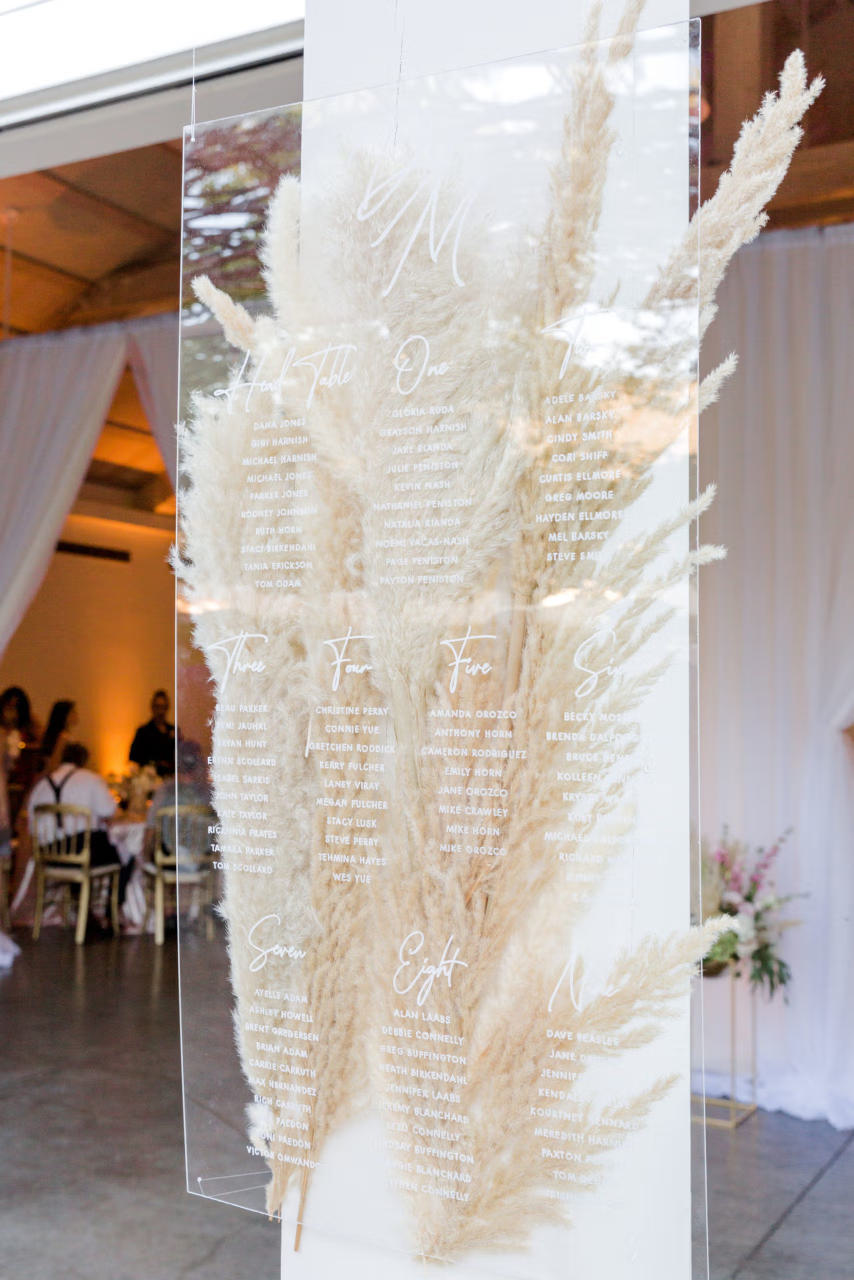

**#2** ·

`Boho_Wedding-5213f4455f181010`  
section: 5. Consider Your Boho Wedding Guests / Make Your Guests Comfortable  
stage1=`heading` stage2=`nearby_vlm`

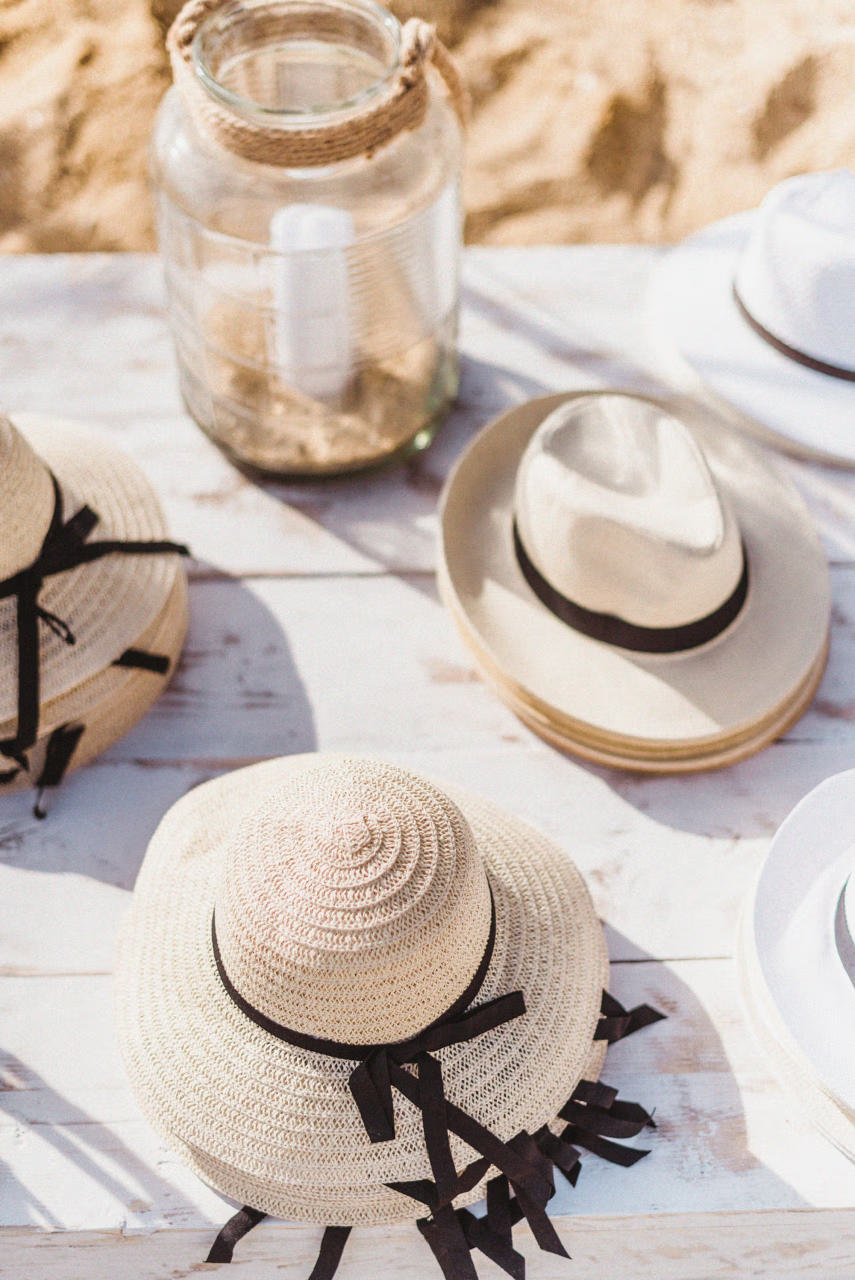

**#3** ·

`Boho_Wedding-3b2ae1b817892616`  
section: 2. Select Your Boho Wedding Venue / Enclose Big Spaces for a More Intimate Feel  
stage1=`heading` stage2=`nearby_vlm`

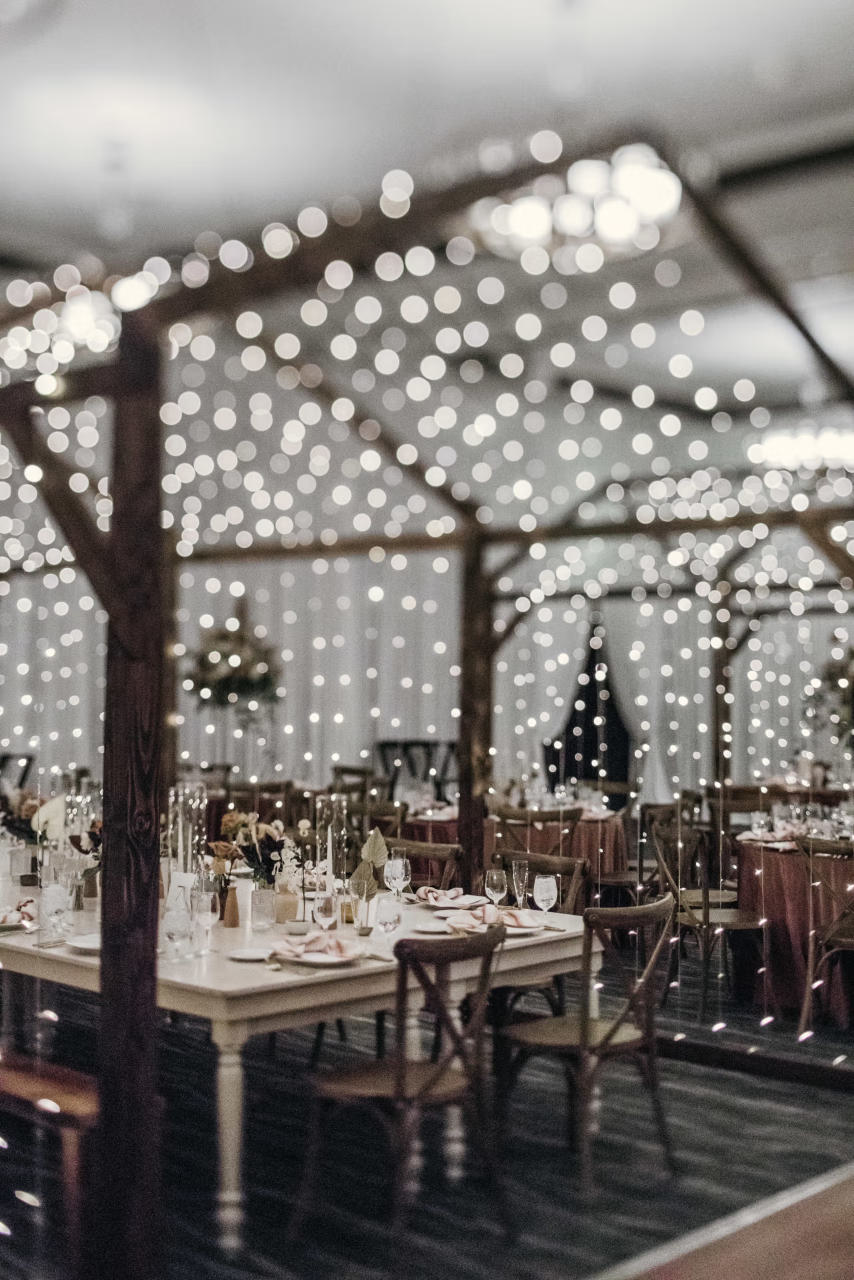

**#4** ·

`Boho_Wedding-621d60e70a5992e5`  
section: 13. Create Luxe Lounge Areas For Your Boho Wedding Guests / Create a Backdrop With Vintage Fabric  
stage1=`heading` stage2=`nearby_vlm`

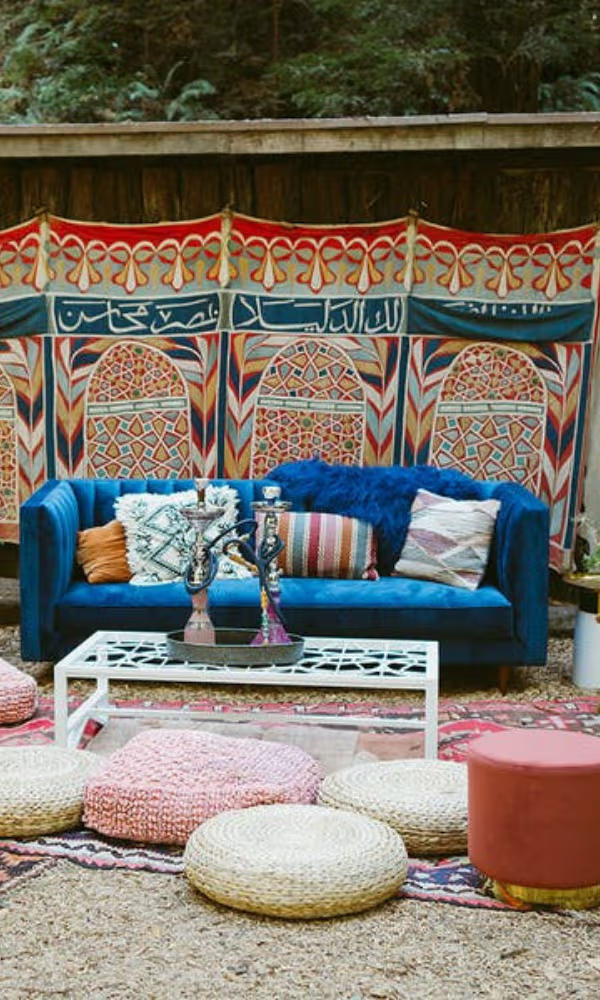

**#5** ·

`Boho_Wedding-3e8b1cecf7c99773`  
section: 13. Create Luxe Lounge Areas For Your Boho Wedding Guests / Create a Luxe Lounge Space Outdoors  
stage1=`heading` stage2=`nearby_vlm`

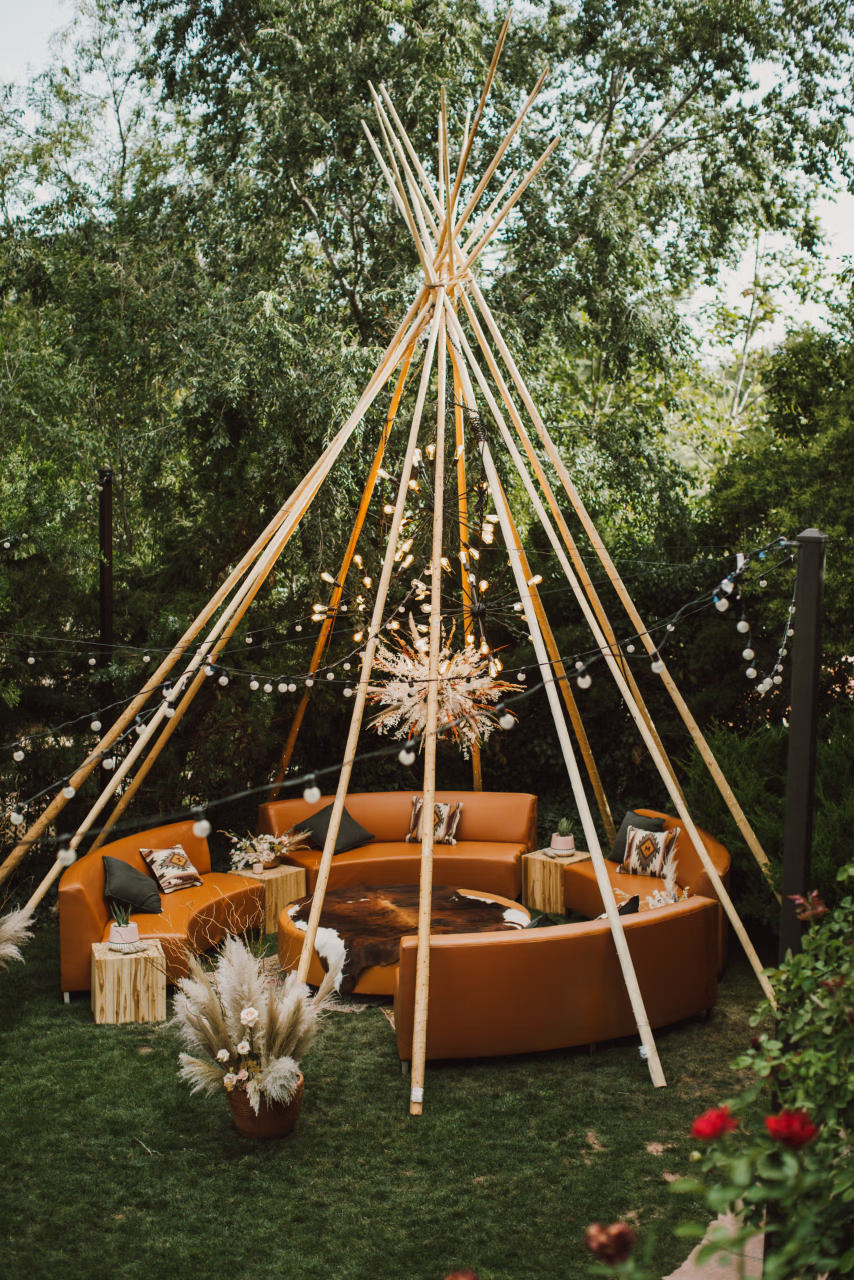

Methods in pivot: ['context_dense', 'fallback_t0.70', 'fallback_t0.75', 'fallback_t0.80', 'fallback_t0.82', 'fallback_t0.85', 'fallback_t0.88', 'retrieve_rerank_k15', 'retrieve_rerank_section_k15']

retrieve_rerank_k15 vs context_dense
  higher coverage for rerank: 9
  higher coverage for dense:  6
  tied:                       78


method,context_dense,retrieve_rerank_k15
case_id,,
B7,0.5000,0.7500
C3,0.5000,1.0000
C4,0.6000,0.8000
MW9,0.2500,0.5000
RU3,0.0000,1.0000
RU7,0.0000,1.0000
WTR2,0.0833,0.1667
WTR8,0.5000,1.0000
WW10,0.5000,1.0000


In [6]:
from IPython.display import Image, Markdown, display

CASE_ID = "B2"
subset = case_results[case_results["case_id"] == CASE_ID]
display(subset[["method", "first_relevant_rank", "coverage_at_5", "retrieved_image_ids"]])

records_by_id = {record["image_id"]: record for record in records_with_stages}
expected = list(subset.iloc[0]["expected_image_ids"])
expected_set = set(expected)
query = subset.iloc[0]["query"]

display(Markdown(f"### Case `{CASE_ID}`\n**Query:** {query}"))


def show_image_row(image_id, *, mark=""):
    record = records_by_id[image_id]
    display(Markdown(
        f"{mark}`{image_id}`  \n"
        f"section: {record.get('section_title', '')} / {record.get('local_heading', '')}  \n"
        f"stage1=`{record.get('stage1_source', '')}` stage2=`{record.get('stage2_source', '')}`"
    ))
    display(Image(filename=record["image_path"], width=180))


display(Markdown("### Expected images"))
for image_id in expected:
    show_image_row(image_id, mark="o")

for method_name in ["context_dense"] + [
    c for c in case_results["method"].unique()
    if str(c).startswith("retrieve_rerank_k")
]:
    row = subset[subset["method"] == method_name]
    if row.empty:
        display(Markdown(f"### Retrieved by `{method_name}`\n_No results row._"))
        continue

    retrieved_ids = list(row.iloc[0]["retrieved_image_ids"])
    cov = row.iloc[0]["coverage_at_5"]
    first_rank = row.iloc[0]["first_relevant_rank"]
    display(Markdown(
        f"### Retrieved by `{method_name}`  \n"
        f"coverage@5={cov} - first_relevant_rank={first_rank}"
    ))
    for rank, image_id in enumerate(retrieved_ids, start=1):
        hit = "o" if image_id in expected_set else "·"
        display(Markdown(f"**#{rank}** {hit}"))
        show_image_row(image_id)

# Disagreement summary across all cases
# Disagreement summary: dense vs each retrieve_rerank_k*
pivot = case_results.pivot_table(
    index="case_id",
    columns="method",
    values="coverage_at_5",
    aggfunc="first",
)

rr_cols = [c for c in pivot.columns if str(c).startswith("retrieve_rerank_k")]
print("Methods in pivot:", list(pivot.columns))
print()

for rr_col in rr_cols:
    better_rr = pivot[pivot[rr_col] > pivot["context_dense"]]
    better_dense = pivot[pivot["context_dense"] > pivot[rr_col]]
    tied = pivot[pivot[rr_col] == pivot["context_dense"]]
    print(f"{rr_col} vs context_dense")
    print("  higher coverage for rerank:", len(better_rr))
    print("  higher coverage for dense: ", len(better_dense))
    print("  tied:                      ", len(tied))
    if len(better_rr):
        display(better_rr[["context_dense", rr_col]].head(10))
    print()

## 7. Recommendation (image method)

In [7]:

PREFERRED_CONFIDENCE = 0.82
MAX_FALLBACK_RATE = 0.10 

fallback = method_metrics[
    method_metrics["method"].astype(str).str.startswith("fallback_t")
].copy()
if fallback.empty:
    raise ValueError("No fallback_t* rows in method_metrics. Re-run the compare cell.")

fallback["confidence_threshold"] = fallback["method"].str.replace(
    "fallback_t", "", regex=False
).astype(float)
fallback["fallback_rate"] = fallback["fallback_rate"].fillna(1.0)
fallback["confidence_distance"] = (
    fallback["confidence_threshold"] - PREFERRED_CONFIDENCE
).abs()

eligible = fallback[fallback["fallback_rate"] <= MAX_FALLBACK_RATE]
if eligible.empty:
    print("WARNING: no fallback met MAX_FALLBACK_RATE; using all fallback rows.")
    eligible = fallback

best = eligible.sort_values(
    ["section_precision_at_5", "confidence_distance", "coverage_at_5", "recall_at_5"],
    ascending=[False, True, False, False],
).iloc[0]

label = str(best["method"])
RECOMMENDED_IMAGE_METHOD = "retrieve_rerank_fallback"
RECOMMENDED_CANDIDATE_K = 15
RECOMMENDED_CONFIDENCE_THRESHOLD = float(best["confidence_threshold"])

display(Markdown(
    "## Locked image retrieval method (auto)\n\n"
    f"- **Rule:** fallback family, `fallback_rate ≤ {MAX_FALLBACK_RATE}`, "
    f"prefer confidence near **{PREFERRED_CONFIDENCE}**, then section precision\n"
    f"- **API method:** `{RECOMMENDED_IMAGE_METHOD}`\n"
    f"- **Table label:** `{label}`\n"
    f"- **candidate_k:** `{RECOMMENDED_CANDIDATE_K}`\n"
    f"- **confidence_threshold:** `{RECOMMENDED_CONFIDENCE_THRESHOLD}`\n"
    f"- **section_precision@5:** **{best['section_precision_at_5']}**\n"
    f"- **coverage@5:** **{best['coverage_at_5']}**\n"
    f"- **recall@5:** **{best['recall_at_5']}**\n"
    f"- **fallback_rate:** **{best['fallback_rate']}**\n"
))
display(Markdown("### Fallback candidates considered"))
display(
    eligible.sort_values(
        ["section_precision_at_5", "confidence_distance"],
        ascending=[False, True],
    )[
        [
            "method",
            "section_precision_at_5",
            "coverage_at_5",
            "recall_at_5",
            "fallback_rate",
            "confidence_threshold",
        ]
    ]
)

RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
payload = {
    "schema_version": 3,
    "image_model": IMAGE_MODEL,
    "top_k": TOP_K,
    "candidate_k": RECOMMENDED_CANDIDATE_K,
    "confidence_threshold": RECOMMENDED_CONFIDENCE_THRESHOLD,
    "cases_file": str(CASES_FILE),
    "case_count": len(evaluation_cases),
    "recommended_image_method": RECOMMENDED_IMAGE_METHOD,
    "recommended_table_label": label,
    "selection_rule": [
        "fallback_family",
        f"fallback_rate<={MAX_FALLBACK_RATE}",
        f"near_confidence={PREFERRED_CONFIDENCE}",
        "section_precision_at_5",
    ],
    "selection_goal": (
        "Auto-lock retrieve_rerank_fallback with low dense escape; "
        "prefer confidence near 0.82 and high section precision."
    ),
    "metrics": method_metrics.to_dict(orient="records"),
    "case_results": case_result_rows,
    "embedding_roots": {
        "context": str(CONTEXT_EMBED_ROOT),
        "stages": str(STAGE_EMBED_ROOT),
    },
}
with RESULTS_FILE.open("w", encoding="utf-8") as file:
    json.dump(payload, file, ensure_ascii=False, indent=2)

print("Saved:", RESULTS_FILE)
print("Locked:", RECOMMENDED_IMAGE_METHOD, "@", RECOMMENDED_CONFIDENCE_THRESHOLD)

## Locked image retrieval method (auto)

- **Rule:** fallback family, `fallback_rate ≤ 0.1`, prefer confidence near **0.82**, then section precision
- **API method:** `retrieve_rerank_fallback`
- **Table label:** `fallback_t0.82`
- **candidate_k:** `15`
- **confidence_threshold:** `0.82`
- **section_precision@5:** **0.6774**
- **coverage@5:** **0.661**
- **recall@5:** **0.6882**
- **fallback_rate:** **0.0323**


### Fallback candidates considered

,method,section_precision_at_5,coverage_at_5,recall_at_5,fallback_rate,confidence_threshold
5,fallback_t0.82,0.6774,0.661,0.6882,0.0323,0.82
4,fallback_t0.80,0.6774,0.661,0.6882,0.0000,0.80
3,fallback_t0.75,0.6774,0.661,0.6882,0.0000,0.75
2,fallback_t0.70,0.6774,0.661,0.6882,0.0000,0.70


Saved: c:\Users\User\Desktop\inmind\gatherly_rag\data\rag\experiments\combined_text_image_retrieval\image_retrieval_method_results.json
Locked: retrieve_rerank_fallback @ 0.82


## 9. Release GPU memory


In [8]:
for name in ["image_model", "text_model", "client"]:
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()
print("Done. GPU allocated MB:", round(torch.cuda.memory_allocated() / 1e6, 2))


Done. GPU allocated MB: 9.57
